In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ct-kidney-dataset-normal-cyst-tumor-and-stone' dataset.
Path to dataset files: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone


In [2]:
import os
os.listdir(os.path.join(path,'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone','CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'))

['Cyst', 'Tumor', 'Stone', 'Normal']

In [3]:
full_path=os.path.join(path,'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone','CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone')

In [4]:
full_path

'/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'

In [5]:
os.listdir(full_path)

['Cyst', 'Tumor', 'Stone', 'Normal']

In [6]:
def count_images(path):

  for folder in os.listdir(path): #stone
    full_folder_path=os.path.join(path,folder)
    print(folder," : ",len(os.listdir(full_folder_path)))
  print()

count_images(full_path)

Cyst  :  3709
Tumor  :  2283
Stone  :  1377
Normal  :  5077



In [7]:
full_path

'/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'

In [8]:
# as you can see the dataset is quite imbalanced so wwe have to computer weights

!pip install split-folders

import splitfolders

splitfolders.ratio(
    os.path.join(full_path),
    output="/content/kidney-split",
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

Copying files: 12446 files [01:27, 142.26 files/s]


In [9]:
train_dir="/content/kidney-split/train"
test_dir="/content/kidney-split/test"
val_dir="/content/kidney-split/val"

In [10]:
directories=[train_dir,test_dir,val_dir]

for i in directories:
  print(i)
  count_images(i)

print()

/content/kidney-split/train
Cyst  :  2967
Stone  :  1101
Normal  :  4061
Tumor  :  1826

/content/kidney-split/test
Cyst  :  372
Stone  :  139
Normal  :  509
Tumor  :  229

/content/kidney-split/val
Cyst  :  370
Stone  :  137
Normal  :  507
Tumor  :  228




In [11]:
os.listdir(os.path.join(val_dir,'Stone'))[0]

'Stone- (818).jpg'

In [12]:
os.path.join(val_dir,'Cyst','Stone- (356).jpg')

'/content/kidney-split/val/Cyst/Stone- (356).jpg'

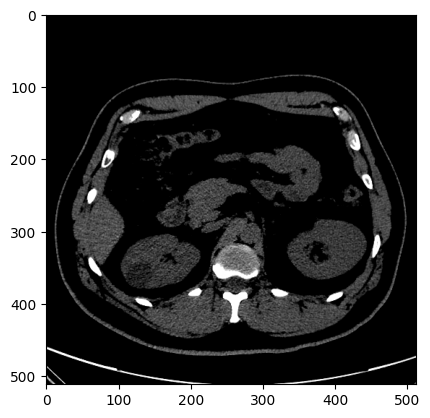

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

full_1_img_path="/content/kidney-split/val/Cyst/Cyst- (10).jpg"
img=Image.open(full_1_img_path)

plt.imshow(img)
plt.show()

In [14]:
train_dir

'/content/kidney-split/train'

In [15]:
img.mode

'RGB'

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator



img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)



train_gen=train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)


val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 9955 images belonging to 4 classes.
Found 1242 images belonging to 4 classes.
Found 1249 images belonging to 4 classes.


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tensorflow as tf

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_labels = list(train_gen.class_indices.keys())
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.8388102460397708), 1: np.float64(0.612841664614627), 2: np.float64(2.260445049954587), 3: np.float64(1.3629518072289157)}


In [19]:
class_labels

['Cyst', 'Normal', 'Stone', 'Tumor']

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 170s 514ms/step - accuracy: 0.5446 - loss: 1.1525 - precision: 0.7585 - recall: 0.2685 - val_accuracy: 0.6296 - val_loss: 0.8505 - val_precision: 0.6884 - val_recall: 0.4855
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 152s 488ms/step - accuracy: 0.6529 - loss: 0.8658 - precision: 0.7351 - recall: 0.5193 - val_accuracy: 0.6441 - val_loss: 0.8509 - val_precision: 0.6741 - val_recall: 0.6111
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 155s 495ms/step - accuracy: 0.7456 - loss: 0.6385 - precision: 0.7852 - recall: 0.6837 - val_accuracy: 0.8720 - val_loss: 0.3305 - val_precision: 0.8942 - val_recall: 0.8502
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 151s 485ms/step - accuracy: 0.8105 - loss: 0.4825 - precision: 0.8374 - recall: 0.7777 - val_accuracy: 0.8841 - val_loss: 0.3191 - val_precision: 0.8924 - val_recall: 0.8680
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 149s 479ms/step - accuracy: 0.8502 - loss: 0.3933 - precision: 0.8656 - recall: 0.8296 - val_accuracy: 0

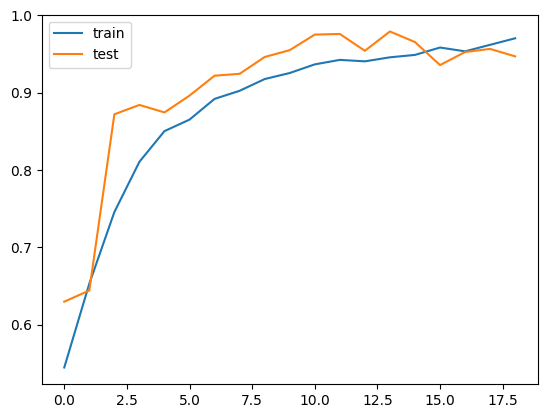

In [21]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()
plt.show(

)

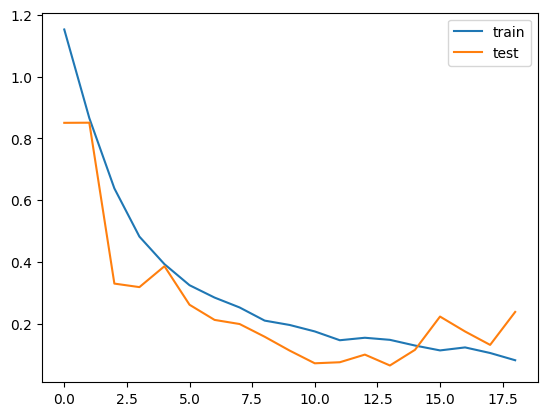

In [22]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show(

)

In [23]:
train_dir

'/content/kidney-split/train'

In [25]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    preprocessing_function=vgg_pre,
    width_shift_range=0.05, height_shift_range=0.05,
    fill_mode='constant', cval=0
)

val_datagen  = ImageDataGenerator(preprocessing_function=vgg_pre)
test_datagen = ImageDataGenerator(preprocessing_function=vgg_pre)



train_ds = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb',
    class_mode='categorical', batch_size=BATCH_SIZE, shuffle=True, seed=42
)

val_ds = val_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb',
    class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False
)

test_ds = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb',
    class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False
)

# sanity check: VGG range should be roughly -120 to +150, NOT 0 to 1
x, y = next(train_ds)
print(x.min(), x.max())

# build model
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
vgg_base.trainable = False   # freeze first

vgg_model = Sequential([
    vgg_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(4, activation='softmax')
])

vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

early = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True
)

vgg_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early],
    class_weight=class_weight_dict
)

Found 9955 images belonging to 4 classes.
Found 1242 images belonging to 4 classes.
Found 1249 images belonging to 4 classes.
-123.68 151.061
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 193s 569ms/step - accuracy: 0.6733 - loss: 0.9985 - precision: 0.7177 - recall: 0.6100 - val_accuracy: 0.8961 - val_loss: 0.3092 - val_precision: 0.9217 - val_recall: 0.8720
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 160s 513ms/step - accuracy: 0.8479 - loss: 0.4026 - precision: 0.8738 - recall: 0.8183 - val_accuracy: 0.9138 - val_loss: 0.2317 - val_precision: 0.9245 - val_recall: 0.9066
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 160s 513ms/step - accuracy: 0.8985 - loss: 0.2657 - precision: 0.9144 - recall: 0.8828 - val_accuracy: 0.9364 - val_loss: 0.1655 - val_precision: 0.9407 - val_recall: 0.9332
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 160s 511ms/step - accuracy: 0.9194 - loss: 0.2197 - precision: 0.9304 - recall: 0.9084 - val_accuracy: 0.9501 - val_loss: 0.1

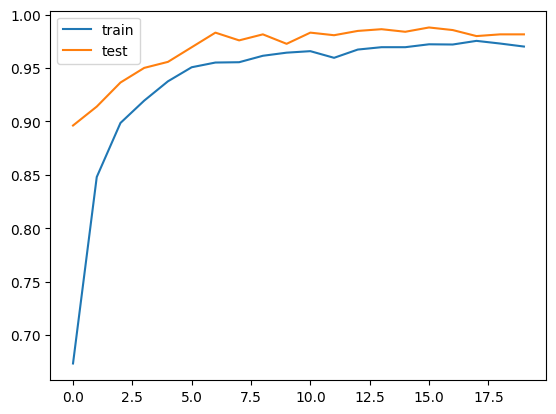

In [28]:
plt.plot(vgg_history.history['accuracy'],label='train')
plt.plot(vgg_history.history['val_accuracy'],label='test')
plt.legend()
plt.show(

)

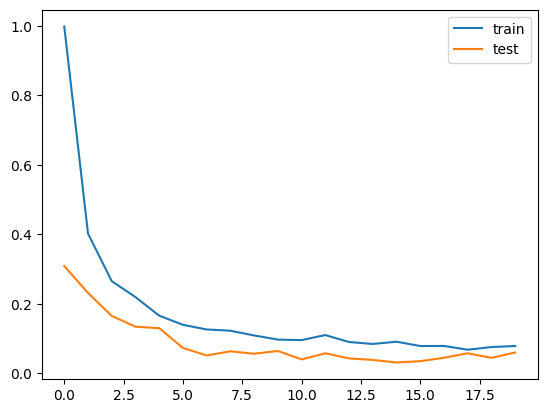

In [29]:
plt.plot(vgg_history.history['loss'],label='train')
plt.plot(vgg_history.history['val_loss'],label='test')
plt.legend()
plt.show(

)

In [30]:
vgg_model.save('kidney_disease_detection.h5')